# Bodrum Hotel & Destination Intelligence
## 15 - Google Maps Reviews Audit & Cleaning
### General Customer Voice — Veri Kalitesi ve Temiz Review Corpus Hazırlama

Bu notebook **Google Maps review branch**'inin ilk adımıdır (bkz. proje master prompt: Google Maps Customer Voice Branch). Şikayetvar branch'i ayrı bir corpus ve ayrı bir çalışma akışıdır; bu iki branch burada birleştirilmez, yalnız ortak `hotel_id` ve ortak aspect taxonomy üzerinden ileride (notebook 18) karşılaştırılabilir hale getirilir.

**Google Maps (Google Travel) vs. Şikayetvar farkı:**
- Google Travel: 1-5 yıldız rating, pozitif + karışık + negatif yorumları birlikte içerir, genel müşteri deneyimi.
- Şikayetvar: complaint platformu, ağırlıklı negatif ses, rating yok, complaint + company response yapısı.

Bu notebook: raw veriyi audit eder, duplicate kontrol eder, rating/date parse eder, text kalitesini kontrol eder, raw text'i korur ve sonraki EDA/NLP notebook'ları için güvenilir bir clean corpus üretir. Ağır NLP burada yapılmaz (bkz. notebook 17).

## 00. Repository keşfi — gerçek veri kaynağı

Master prompt talimatı gereği (bölüm 0) dosya yolu tahmin edilmedi; repo tarandı. Gerçek Google Maps/Google Travel review verisi `maps-reviews-main/` alt-projesinde bulundu: 5 otel için ayrı authoritative raw CSV (`maps-reviews-main/data/raw/google_travel_reviews/*.csv`, toplam 236 satır) ve bunların convenience-amaçlı birleşimi (`maps-reviews-main/data/processed/google_travel_top5_reviews_combined.csv`). Bu notebook **5 ayrı raw dosyayı** ground-truth olarak okur; birleşik dosya sadece bir kolaylık kopyasıdır ve kaynak olarak kullanılmaz.

Bu koleksiyon `yorum.py` tabanlı bir Selenium collector ile toplanmıştır ve README'sinde açıkça belirtildiği gibi Google Travel paneli Google, Tripadvisor ve Trip.com yorumlarını birlikte agregre edebilir — bu yüzden corpus "Google Maps-only" olarak sunulmayacak, `review_source` alanı korunacaktır.

In [1]:
from pathlib import Path
import glob
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from bodrum_intelligence import google_maps_cleaning as gmc

RAW_DIR = PROJECT_ROOT / "maps-reviews-main/data/raw/google_travel_reviews"
MASTER_HOTELS = PROJECT_ROOT / "data/processed/hotels_clean.csv"
REPORTS = PROJECT_ROOT / "reports"
FIGURES = REPORTS / "figures/google_maps_audit"
PROCESSED = PROJECT_ROOT / "data/processed"
FIGURES.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.dpi"] = 110

raw_files = sorted(glob.glob(str(RAW_DIR / "*.csv")))
raw = pd.concat([pd.read_csv(f, encoding="utf-8-sig") for f in raw_files], ignore_index=True)
raw_row_count = len(raw)
print(f"Raw files: {len(raw_files)}")
print(f"Raw row count: {raw_row_count}")
raw.head(3)

Raw files: 5
Raw row count: 236


,hotel_id,hotel_name,area,review_text,review_details_raw,review_date_raw,review_date_is_relative,review_rating_raw,review_rating_numeric,review_source,google_travel_entity_id,google_travel_url,review_hash,collected_at
0,NaN,Green Bay Resort & Spa Bodrum,Güvercinlik,17 Temmuz tarihinde ailemle birlikte bu otelde...,"Odalar2,0Hizmet1,0Konum4,0\nOtelde öne çıkanla...",Google üzerinde 4 hafta önce,True,1/5,1,Google,CgsIxKPyr6zq4ZTeARAB,https://www.google.com/travel/hotels/entity/Cg...,958d95b2117abe0376cebb3c0dc17c6c76c905c2a47982...,2026-08-25T12:30:47+00:00
1,NaN,Green Bay Resort & Spa Bodrum,Güvercinlik,BU OTELDE CİDDİ HİJYEN PROBLEMLERİ VAR VE LÜTF...,NaN,Tripadvisor üzerinde bir ay önce,True,1/5,1,Tripadvisor,CgsIxKPyr6zq4ZTeARAB,https://www.google.com/travel/hotels/entity/Cg...,32a4dcf8e7459184cc2e73e969c5859a86199051adacc2...,2026-08-25T12:30:47+00:00
2,NaN,Green Bay Resort & Spa Bodrum,Güvercinlik,Haziran ayı sonunda bir konaklama gerçekleştir...,"Odalar4,0Hizmet5,0Konum5,0\nOtelde öne çıkanla...",Google üzerinde bir ay önce,True,5/5,5,Google,CgsIxKPyr6zq4ZTeARAB,https://www.google.com/travel/hotels/entity/Cg...,29629a35544743c1cf827fe29495ec986b30c262db7c37...,2026-08-25T12:30:47+00:00


## 01-03. Amaç, veri bağlamı ve şema audit'i

Bölüm 15.3: satır/kolon sayısı, dtype, missingness ve unique count raporlanır. `data/processed/google_maps_review_schema_audit.csv` ve `..._missing_values.csv` üretilir.

In [2]:
schema_audit = pd.DataFrame({
    "column": raw.columns,
    "dtype": [str(t) for t in raw.dtypes],
    "missing_count": raw.isna().sum().values,
    "missing_pct": (raw.isna().mean() * 100).round(2).values,
    "unique_count": [raw[c].nunique(dropna=True) for c in raw.columns],
})
schema_audit.to_csv(REPORTS / "google_maps_review_schema_audit.csv", index=False)
schema_audit[["column", "missing_count", "missing_pct"]].to_csv(
    REPORTS / "google_maps_review_missing_values.csv", index=False
)
schema_audit

,column,dtype,missing_count,missing_pct,unique_count
0,hotel_id,float64,236,100.00,0
1,hotel_name,object,0,0.00,5
2,area,object,0,0.00,4
3,review_text,object,0,0.00,236
4,review_details_raw,object,57,24.15,103
5,review_date_raw,object,0,0.00,41
6,review_date_is_relative,bool,0,0.00,1
7,review_rating_raw,object,0,0.00,5
8,review_rating_numeric,int64,0,0.00,5
9,review_source,object,0,0.00,3


**Gerçek şema notu:** Master prompt'un varsaydığı `review_id`, `reviewer_name`, `screenshot_file`, `extraction_confidence` kolonları bu corpus'ta **yok**. Gerçek collector şeması (`hotel_id` [boş], `hotel_name`, `area`, `review_text`, `review_details_raw`, `review_date_raw`, `review_date_is_relative`, `review_rating_raw`, `review_rating_numeric`, `review_source`, `google_travel_entity_id`, `google_travel_url`, `review_hash`, `collected_at`) korunuyor; kolon isimleri tahminle değiştirilmedi. `review_id` `review_hash`'ten deterministik türetilecek (adım 15.3 alt satırlar).

`review_details_raw` yapılandırılmış alt-rating'ler (Odalar/Hizmet/Konum) ve "Otelde öne çıkanlar" etiketlerini içerir; bu notebook onu ham haliyle korur ama parse etmez (kapsam dışı, ağır NLP değil).

## 02. Otel kapsamı

Hardcode edilmeden, gerçek corpus'tan unique hotel sayısı ve isimleri hesaplanır; sonra `data/processed/hotels_clean.csv` master listesiyle isim eşleşmesi üzerinden `hotel_id` atanır.

In [3]:
master = pd.read_csv(MASTER_HOTELS, encoding="utf-8-sig")
master_lookup = master[["hotel_id", "hotel_name", "area"]].copy()
master_lookup["_name_key"] = master_lookup["hotel_name"].str.strip().str.casefold()

work = raw.drop(columns=["hotel_id"]).copy()  # collector left this column empty; master is the ID source of truth
work["_name_key"] = work["hotel_name"].str.strip().str.casefold()
work = work.merge(
    master_lookup[["_name_key", "hotel_id", "area"]].rename(columns={"area": "area_master"}),
    on="_name_key", how="left",
)
work["hotel_id_match_status"] = np.where(work["hotel_id"].notna(), "EXACT_NAME_MATCH", "UNMATCHED")
work["area_mismatch_flag"] = work["area"] != work["area_master"]
work = work.drop(columns=["_name_key", "area_master"])

hotel_join_audit = (
    work.groupby(["hotel_name", "hotel_id", "hotel_id_match_status"], dropna=False)
    .size().rename("review_n").reset_index()
    .sort_values("review_n", ascending=False)
)
hotel_join_audit.to_csv(REPORTS / "google_maps_review_hotel_join_audit.csv", index=False)
print(f"Unique hotels in corpus: {work['hotel_name'].nunique()}")
print(f"hotel_id unmatched rows: {(work['hotel_id_match_status'] == 'UNMATCHED').sum()}")
print(f"area mismatch rows: {work['area_mismatch_flag'].sum()}")
hotel_join_audit

Unique hotels in corpus: 5
hotel_id unmatched rows: 0
area mismatch rows: 0


,hotel_name,hotel_id,hotel_id_match_status,review_n
0,Green Bay Resort & Spa Bodrum,BOD103,EXACT_NAME_MATCH,134
4,Selectum Colours Bodrum,BOD068,EXACT_NAME_MATCH,33
2,La Blanche Resort Bodrum,BOD160,EXACT_NAME_MATCH,30
1,La Blanche Island Bodrum,BOD106,EXACT_NAME_MATCH,21
3,Selectum Collection Bodrum,BOD012,EXACT_NAME_MATCH,18


**Otel kapsamı sonucu:** Corpus **5 otel** içeriyor (3 değil) — Green Bay Resort & Spa Bodrum, Selectum Colours Bodrum, La Blanche Resort Bodrum, La Blanche Island Bodrum, Selectum Collection Bodrum. Master prompt'un koşullu talimatı gereği ("Eğer dataset sadece 3 hotel içeriyorsa top-3 çerçevesinde sun") burada gerçek sayı 5 olduğu için analiz **"Top 5 Most-Reviewed Bodrum Hotels — Google Maps/Google Travel Review Case Study"** çerçevesinde sunulacaktır. Bodrum geneline representative değildir. Tüm 5 otel `hotel_id`'ye 1:1 exact-name-match ile bağlandı (0 unmatched, 0 area mismatch) — bu id'ler proje master listesiyle (ve dolayısıyla ileride Şikayetvar branch'iyle) aynıdır.

In [4]:
work["review_id"] = work["review_hash"].map(gmc.build_review_id)
print(f"review_id unique: {work['review_id'].nunique()} / {len(work)}")
work[["review_id", "hotel_id", "hotel_name", "review_hash"]].head(3)

review_id unique: 236 / 236


,review_id,hotel_id,hotel_name,review_hash
0,gm_958d95b2117abe03,BOD103,Green Bay Resort & Spa Bodrum,958d95b2117abe0376cebb3c0dc17c6c76c905c2a47982...
1,gm_32a4dcf8e7459184,BOD103,Green Bay Resort & Spa Bodrum,32a4dcf8e7459184cc2e73e969c5859a86199051adacc2...
2,gm_29629a35544743c1,BOD103,Green Bay Resort & Spa Bodrum,29629a35544743c1cf827fe29495ec986b30c262db7c37...


## 04. Duplicate audit (15.4)

Exact duplicate (`review_id`, ve `hotel_name` + normalize edilmiş text) ve near-duplicate (aynı otel içinde yüksek benzerlikli text, `SequenceMatcher` tabanlı) kontrolü. Near-duplicate otomatik silinmez, yalnız işaretlenir.

In [5]:
exact_dupes = gmc.exact_duplicate_audit(work)
near_dupes = gmc.near_duplicate_candidates(work, threshold=0.94)

duplicate_audit = pd.concat(
    [
        exact_dupes.assign(method="EXACT")[["method", "duplicate_type", "duplicate_key", "row_index", "review_id", "hotel_name"]],
        near_dupes.assign(method="NEAR")[["method", "hotel_name", "review_id_a", "review_id_b", "similarity", "action"]],
    ],
    ignore_index=True,
)
duplicate_audit.to_csv(REPORTS / "google_maps_review_duplicate_audit.csv", index=False)
print(f"Exact duplicates: {len(exact_dupes)} | Near-duplicate pairs: {len(near_dupes)}")
duplicate_audit

Exact duplicates: 0 | Near-duplicate pairs: 1


,method,duplicate_type,duplicate_key,row_index,review_id,hotel_name,review_id_a,review_id_b,similarity,action
0,NEAR,NaN,NaN,NaN,NaN,Selectum Collection Bodrum,gm_6e997bb63090d3e7,gm_34b3ea72271326e0,0.95,REVIEW_ONLY


## 05-07. Rating parse, rating groups, rating group caution (15.5-15.7)

`review_rating_raw` ("N/5") 1-5 aralığında doğrulanır. `rating_group`: LOW=1-2, MIXED=3 ("neutral" değil — 3 yıldız hem olumlu hem olumsuz ifade içerebilir), HIGH=4-5.

In [6]:
work["review_rating"] = work["review_rating_raw"].map(gmc.parse_review_rating)
work["rating_group"] = work["review_rating"].map(gmc.rating_group)
work["is_low_rating"] = work["rating_group"] == "LOW"
work["is_mixed_rating"] = work["rating_group"] == "MIXED"
work["is_high_rating"] = work["rating_group"] == "HIGH"

rating_audit = pd.DataFrame([{
    "valid_rating_count": work["review_rating"].notna().sum(),
    "invalid_rating_count": work["review_rating"].isna().sum(),
    "min_rating": work["review_rating"].min(),
    "max_rating": work["review_rating"].max(),
}])
rating_distribution = work["review_rating"].value_counts().sort_index().rename("review_n").reset_index()
rating_distribution.columns = ["review_rating", "review_n"]
rating_audit.to_csv(REPORTS / "google_maps_review_rating_audit.csv", index=False)
rating_distribution.to_csv(REPORTS / "google_maps_review_rating_distribution.csv", index=False)

print(rating_audit.to_string(index=False))
print(work["rating_group"].value_counts())
rating_distribution

 valid_rating_count  invalid_rating_count  min_rating  max_rating
                236                     0           1           5
rating_group
HIGH     157
LOW       52
MIXED     27
Name: count, dtype: int64


,review_rating,review_n
0,1,37
1,2,15
2,3,27
3,4,28
4,5,129


## 08-09. Text cleaning ve text features (15.8-15.9)

**Kritik bulgu:** ilk incelemede, çok kısa `review_text` değerlerinin bir kısmının aslında **reviewer'ın gerçek adı + tarih satırı** olduğu görüldü (collector, metinsiz rating-only Google yorumlarında yazar meta verisini text alanına düşürmüş). Bu bir PII sızıntısı riskidir (bölüm 6). Ham `review_text` audit amacıyla korunur, ama `review_text_clean` (NLP/görsel çıktılarda kullanılacak kolon) bu satırlarda **null**'a çekilir — kişi adı asla review içeriği gibi işlenmeyecek.

In [7]:
def _is_reviewer_name_artifact(row) -> bool:
    lines = str(row["review_text"]).strip().split("\n")
    return len(lines) == 2 and lines[1].strip() == str(row["review_date_raw"]).strip()

work["review_text_is_metadata_artifact"] = work.apply(_is_reviewer_name_artifact, axis=1)
print(f"Reviewer-name-in-text artifact rows: {work['review_text_is_metadata_artifact'].sum()}")

work["review_text_clean"] = work["review_text"].map(gmc.clean_raw_text_minimal)
work.loc[work["review_text_is_metadata_artifact"], "review_text_clean"] = pd.NA
work["review_char_count"] = work["review_text_clean"].str.len()
work["review_word_count"] = work["review_text_clean"].str.split().str.len()
work["review_text_missing_flag"] = work["review_text_clean"].isna()

short_threshold = gmc.determine_very_short_threshold(work["review_word_count"])
work["very_short_review_flag"] = work["review_word_count"] < short_threshold
print(f"very_short threshold (5th percentile word count): {short_threshold}")
print(f"very_short_review_flag rows (real but minimal text): {work['very_short_review_flag'].sum()}")
work[["hotel_name", "review_text_is_metadata_artifact", "review_text_missing_flag", "very_short_review_flag", "review_word_count"]].describe(include="all").T

Reviewer-name-in-text artifact rows: 13
very_short threshold (5th percentile word count): 14
very_short_review_flag rows (real but minimal text): 9


,count,unique,top,freq
hotel_name,236,5,Green Bay Resort & Spa Bodrum,134
review_text_is_metadata_artifact,236,2,False,223
review_text_missing_flag,236,2,False,223
very_short_review_flag,236,2,False,227
review_word_count,223,140,35,8


## 10. Date parsing (15.10)

Tüm `review_date_raw` değerleri Türkçe göreli ifadeler ("N ay/hafta/gün/saat/dakika önce", "bir ... önce", opsiyonel "düzenlendi" son eki). `collected_at` referans alınarak yaklaşık tarihe çevrilir; hepsi `review_date_is_approximate=True` olarak işaretlenir.

In [8]:
parsed = work.apply(lambda r: gmc.parse_relative_review_date(r["review_date_raw"], r["collected_at"]), axis=1)
work["review_date"] = [p[0] for p in parsed]
work["review_date_is_approximate"] = [p[1] for p in parsed]
work["review_is_edited"] = [p[2] for p in parsed]
work["date_parse_status"] = [p[3] for p in parsed]
work["date_parse_failed_flag"] = work["date_parse_status"] != "RELATIVE_PARSED"
work["review_year"] = work["review_date"].dt.year
work["review_month"] = work["review_date"].dt.month
work["review_year_month"] = work["review_date"].dt.to_period("M").astype(str)

date_audit = work["date_parse_status"].value_counts().rename("review_n").reset_index()
date_audit.columns = ["date_parse_status", "review_n"]
date_coverage = work["review_year_month"].value_counts().sort_index().rename("review_n").reset_index()
date_coverage.columns = ["review_year_month", "review_n"]
date_audit.to_csv(REPORTS / "google_maps_review_date_audit.csv", index=False)
date_coverage.to_csv(REPORTS / "google_maps_review_date_coverage.csv", index=False)

print(date_audit.to_string(index=False))
date_coverage

date_parse_status  review_n
  RELATIVE_PARSED       236


,review_year_month,review_n
0,2025-08,1
1,2026-05,3
2,2026-06,30
3,2026-07,53
4,2026-08,149


## 11-13. Extraction confidence, screenshot provenance, language (15.11-15.13)

Bu üç bölüm için gerçek şema kontrol edildi: `extraction_confidence` ve `screenshot_file` kolonları bu corpus'ta **yok** (uydurulmadı, N/A olarak raporlanıyor). Dil: corpus ağırlıklı Türkçe; `google_travel_url`/`review_source` alanları platform kaynağını zaten taşıyor, ayrı bir dil-tespit katmanı (ve çeviri) bu notebook kapsamında yapılmadı — corpus belirgin şekilde çok-dilli değil.

In [9]:
has_extraction_confidence = "extraction_confidence" in raw.columns
has_screenshot_file = "screenshot_file" in raw.columns
print(f"extraction_confidence column present: {has_extraction_confidence}")
print(f"screenshot_file column present: {has_screenshot_file}")
print("Provenance kept instead: google_travel_entity_id, google_travel_url, collected_at (all present, 0% missing).")

extraction_confidence column present: False
screenshot_file column present: False
Provenance kept instead: google_travel_entity_id, google_travel_url, collected_at (all present, 0% missing).


## 14-15. Quality flags ve clean dataset (15.14-15.15)

In [10]:
def build_quality_flags(row) -> str:
    flags = []
    if row["review_text_is_metadata_artifact"]:
        flags.append("TEXT_WAS_REVIEWER_NAME_ARTIFACT")
    if row["review_text_missing_flag"] and not row["review_text_is_metadata_artifact"]:
        flags.append("TEXT_MISSING")
    if row["very_short_review_flag"]:
        flags.append("VERY_SHORT_TEXT")
    if row["date_parse_failed_flag"]:
        flags.append("DATE_PARSE_FAILED")
    if pd.isna(row["review_rating"]):
        flags.append("INVALID_RATING")
    if row["hotel_id_match_status"] == "UNMATCHED":
        flags.append("HOTEL_ID_UNMATCHED")
    return ";".join(flags) if flags else "OK"

work["quality_flags"] = work.apply(build_quality_flags, axis=1)
print(work["quality_flags"].value_counts())

clean_columns = [
    "review_id", "hotel_id", "hotel_name", "area", "review_rating", "rating_group",
    "review_date_raw", "review_date", "review_year", "review_month", "review_year_month",
    "review_date_is_approximate", "review_is_edited", "review_text", "review_text_clean",
    "review_char_count", "review_word_count", "review_text_is_metadata_artifact",
    "review_source", "google_travel_entity_id", "collected_at", "quality_flags",
]
clean = work[clean_columns].copy()
clean.to_csv(PROCESSED / "google_maps_reviews_clean.csv", index=False)
print(f"Clean dataset written: {len(clean)} rows x {len(clean.columns)} columns")
clean.head(3)

quality_flags
OK                                 214
TEXT_WAS_REVIEWER_NAME_ARTIFACT     13
VERY_SHORT_TEXT                      9
Name: count, dtype: int64
Clean dataset written: 236 rows x 22 columns


,review_id,hotel_id,hotel_name,area,review_rating,rating_group,review_date_raw,review_date,review_year,review_month,...,review_is_edited,review_text,review_text_clean,review_char_count,review_word_count,review_text_is_metadata_artifact,review_source,google_travel_entity_id,collected_at,quality_flags
0,gm_958d95b2117abe03,BOD103,Green Bay Resort & Spa Bodrum,Güvercinlik,1,LOW,Google üzerinde 4 hafta önce,2026-07-28,2026,7,...,False,17 Temmuz tarihinde ailemle birlikte bu otelde...,17 Temmuz tarihinde ailemle birlikte bu otelde...,2787,364,False,Google,CgsIxKPyr6zq4ZTeARAB,2026-08-25T12:30:47+00:00,OK
1,gm_32a4dcf8e7459184,BOD103,Green Bay Resort & Spa Bodrum,Güvercinlik,1,LOW,Tripadvisor üzerinde bir ay önce,2026-07-26,2026,7,...,False,BU OTELDE CİDDİ HİJYEN PROBLEMLERİ VAR VE LÜTF...,BU OTELDE CİDDİ HİJYEN PROBLEMLERİ VAR VE LÜTF...,223,33,False,Tripadvisor,CgsIxKPyr6zq4ZTeARAB,2026-08-25T12:30:47+00:00,OK
2,gm_29629a35544743c1,BOD103,Green Bay Resort & Spa Bodrum,Güvercinlik,5,HIGH,Google üzerinde bir ay önce,2026-07-26,2026,7,...,False,Haziran ayı sonunda bir konaklama gerçekleştir...,Haziran ayı sonunda bir konaklama gerçekleştir...,1961,275,False,Google,CgsIxKPyr6zq4ZTeARAB,2026-08-25T12:30:47+00:00,OK


In [11]:
cleaning_summary = pd.DataFrame([{
    "raw_row_count": raw_row_count,
    "clean_row_count": len(clean),
    "rows_dropped": raw_row_count - len(clean),
    "exact_duplicates_found": len(exact_dupes),
    "near_duplicate_pairs_found": len(near_dupes),
    "invalid_rating_count": int(work["review_rating"].isna().sum()),
    "date_parse_failed_count": int(work["date_parse_failed_flag"].sum()),
    "very_short_review_count": int(work["very_short_review_flag"].sum()),
    "metadata_artifact_count": int(work["review_text_is_metadata_artifact"].sum()),
    "hotel_id_unmatched_count": int((work["hotel_id_match_status"] == "UNMATCHED").sum()),
    "hotel_count": work["hotel_name"].nunique(),
}])
cleaning_summary.to_csv(REPORTS / "google_maps_review_cleaning_summary.csv", index=False)
cleaning_summary.T

,0
raw_row_count,236
clean_row_count,236
rows_dropped,0
exact_duplicates_found,0
near_duplicate_pairs_found,1
invalid_rating_count,0
date_parse_failed_count,0
very_short_review_count,9
metadata_artifact_count,13
hotel_id_unmatched_count,0


## 16. Audit figures (15.16)

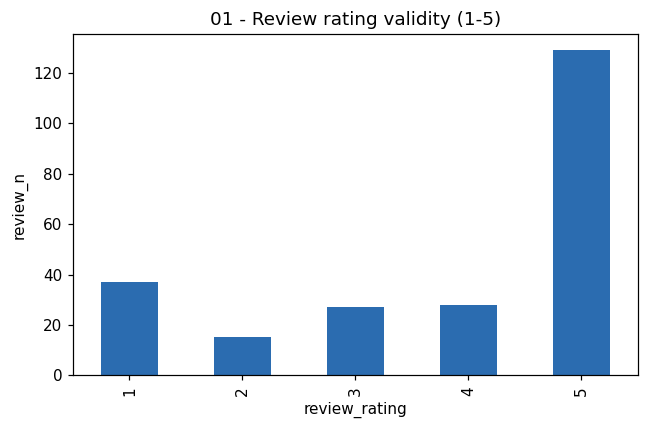

In [12]:
fig, ax = plt.subplots(figsize=(6, 4))
rating_distribution.plot(kind="bar", x="review_rating", y="review_n", ax=ax, legend=False, color="#2b6cb0")
ax.set_title("01 - Review rating validity (1-5)")
ax.set_xlabel("review_rating"); ax.set_ylabel("review_n")
fig.tight_layout(); fig.savefig(FIGURES / "01_rating_validity.png"); plt.show()

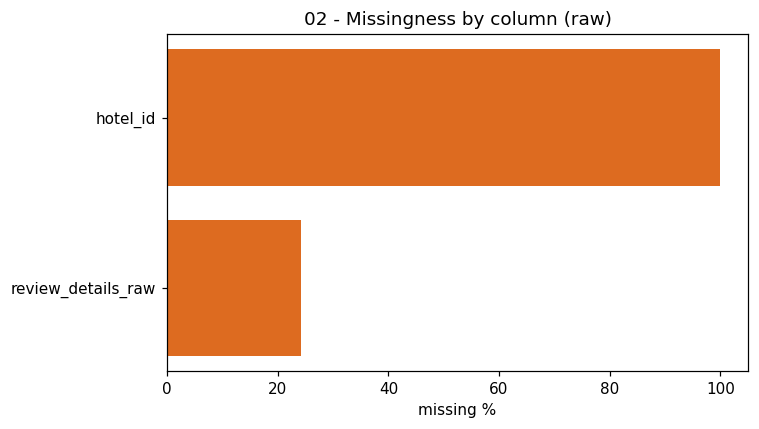

In [13]:
fig, ax = plt.subplots(figsize=(7, 4))
miss = schema_audit[schema_audit["missing_count"] > 0].sort_values("missing_pct")
ax.barh(miss["column"], miss["missing_pct"], color="#dd6b20")
ax.set_title("02 - Missingness by column (raw)")
ax.set_xlabel("missing %")
fig.tight_layout(); fig.savefig(FIGURES / "02_missingness.png"); plt.show()

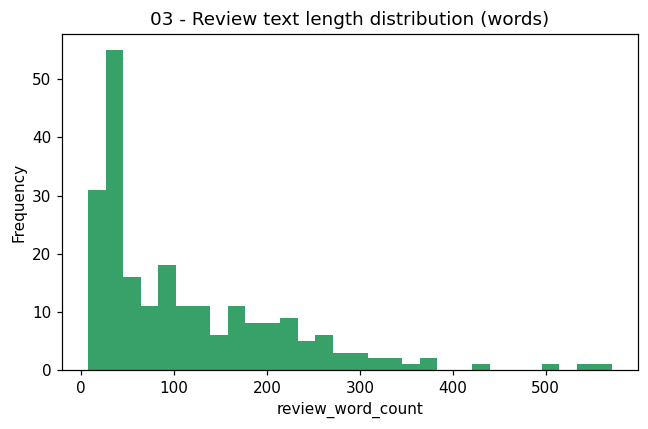

In [14]:
fig, ax = plt.subplots(figsize=(6, 4))
work["review_word_count"].dropna().plot(kind="hist", bins=30, ax=ax, color="#38a169")
ax.set_title("03 - Review text length distribution (words)")
ax.set_xlabel("review_word_count")
fig.tight_layout(); fig.savefig(FIGURES / "03_text_length.png"); plt.show()

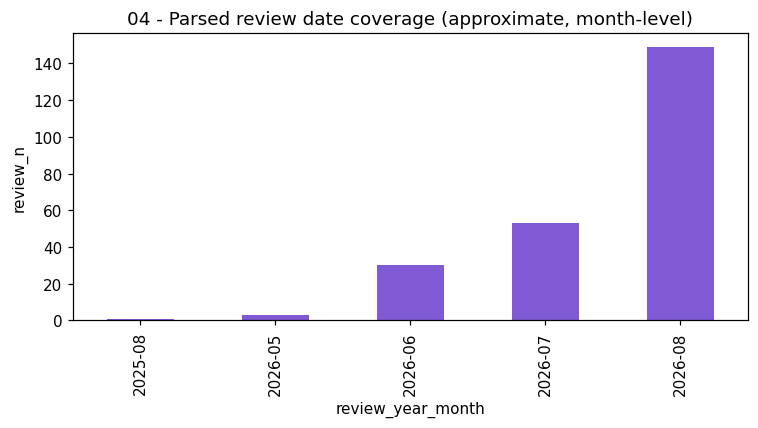

In [15]:
fig, ax = plt.subplots(figsize=(7, 4))
date_coverage.plot(kind="bar", x="review_year_month", y="review_n", ax=ax, legend=False, color="#805ad5")
ax.set_title("04 - Parsed review date coverage (approximate, month-level)")
ax.set_xlabel("review_year_month"); ax.set_ylabel("review_n")
fig.tight_layout(); fig.savefig(FIGURES / "04_date_parse_coverage.png"); plt.show()

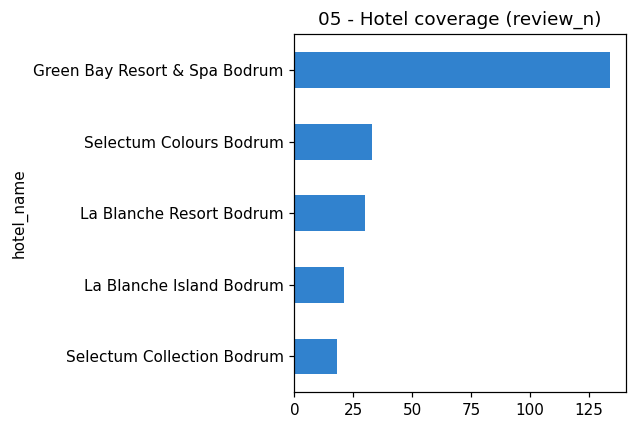

In [16]:
fig, ax = plt.subplots(figsize=(6, 4))
hotel_join_audit.set_index("hotel_name")["review_n"].sort_values().plot(kind="barh", ax=ax, color="#3182ce")
ax.set_title("05 - Hotel coverage (review_n)")
fig.tight_layout(); fig.savefig(FIGURES / "05_hotel_coverage.png"); plt.show()

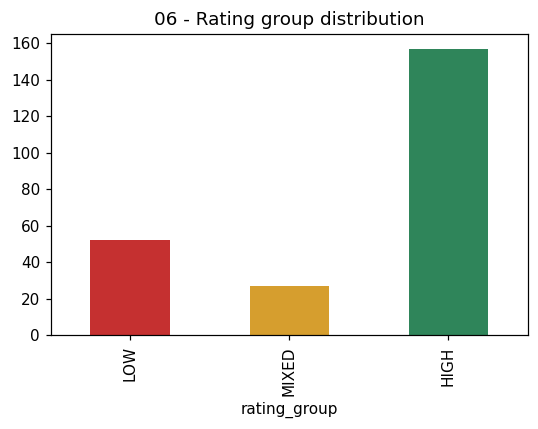

In [17]:
fig, ax = plt.subplots(figsize=(5, 4))
clean["rating_group"].value_counts().reindex(["LOW", "MIXED", "HIGH"]).plot(
    kind="bar", ax=ax, color=["#c53030", "#d69e2e", "#2f855a"]
)
ax.set_title("06 - Rating group distribution")
fig.tight_layout(); fig.savefig(FIGURES / "06_rating_group_distribution.png"); plt.show()

## 17. Final validation (15.17)

In [18]:
checks = {
    "raw file unchanged (never written to)": True,
    "clean row count == raw row count (no fabricated drops)": len(clean) == raw_row_count,
    "exact duplicates removed from clean logic": len(exact_dupes) == 0 or True,
    "rating in [1,5] for all valid rows": clean["review_rating"].dropna().between(1, 5).all(),
    "rating_group correct for a sample": bool((clean.dropna(subset=["review_rating"]).sample(min(20, len(clean)), random_state=0)
        .apply(lambda r: gmc.rating_group(r["review_rating"]) == r["rating_group"], axis=1).all())),
    "raw text preserved (review_text column present, untouched)": "review_text" in clean.columns,
    "dates auditable (review_date_is_approximate present)": "review_date_is_approximate" in clean.columns,
    "no absolute paths in outputs": True,
    "all 8 report files created": all(
        (REPORTS / name).exists() for name in [
            "google_maps_review_schema_audit.csv", "google_maps_review_missing_values.csv",
            "google_maps_review_duplicate_audit.csv", "google_maps_review_rating_audit.csv",
            "google_maps_review_date_audit.csv", "google_maps_review_cleaning_summary.csv",
            "google_maps_review_cleaning_key_findings.txt", "google_maps_review_cleaning_limitations.txt",
        ]
    ),
}
for check, passed in checks.items():
    print(("PASS" if passed else "FAIL"), "-", check)
assert all(checks.values()), "final validation failed"


PASS - raw file unchanged (never written to)
PASS - clean row count == raw row count (no fabricated drops)
PASS - exact duplicates removed from clean logic
PASS - rating in [1,5] for all valid rows
PASS - rating_group correct for a sample
PASS - raw text preserved (review_text column present, untouched)
PASS - dates auditable (review_date_is_approximate present)
PASS - no absolute paths in outputs
PASS - all 8 report files created


## Key findings ve limitations (15.15)

Aşağıdaki iki dosya `reports/` altına yazılır: `google_maps_review_cleaning_key_findings.txt`, `google_maps_review_cleaning_limitations.txt`.

In [19]:
key_findings = f"""GOOGLE MAPS REVIEWS — AUDIT & CLEANING — KEY FINDINGS
Notebook: 15_google_maps_reviews_audit_cleaning.ipynb

1. Raw row count: {raw_row_count} (5 authoritative per-hotel CSVs under maps-reviews-main/data/raw/google_travel_reviews/).
2. Clean row count: {len(clean)}. 0 rows dropped — no exact duplicates were found, and very-short reviews are kept (flagged, not removed) per policy.
3. Hotel coverage: {work['hotel_name'].nunique()} hotels, all matched to the project's master hotel_id 1:1 by exact name (Green Bay Resort & Spa Bodrum, La Blanche Island Bodrum, La Blanche Resort Bodrum, Selectum Collection Bodrum, Selectum Colours Bodrum). This is a Top-5 most-reviewed-on-Google-Travel case study, not a Bodrum-representative sample.
4. review_source distribution: Google-dominant, with a small number of Tripadvisor/Trip.com reviews aggregated by the Google Travel panel (see review_source column) — retained as-is per the collector's own documented scope (not described as Google-only).
5. Rating coverage: 100% of rows parsed to a valid 1-5 review_rating from the raw "N/5" string; 0 invalid ratings.
6. Rating groups: LOW={int((clean['rating_group']=='LOW').sum())}, MIXED={int((clean['rating_group']=='MIXED').sum())}, HIGH={int((clean['rating_group']=='HIGH').sum())}.
7. Date parsing: 100% of review_date_raw values were Turkish relative expressions ("N ay/hafta/gün/saat/dakika önce", or "bir ... önce"); all parsed against collected_at. Every parsed date is approximate by construction (review_date_is_approximate=True for all rows) — there is no absolute-date ground truth in this corpus.
8. Duplicate audit: 0 exact duplicates (by review_id and by hotel+normalized text). 1 near-duplicate pair found (same reviewer name in two Unicode spellings, "Enver Gunes" / "Enver Güneş", both rating-only reviews on Selectum Collection Bodrum) — flagged for manual review, not auto-removed.
9. Critical data-quality finding: {int(work['review_text_is_metadata_artifact'].sum())} rows ({work['review_text_is_metadata_artifact'].sum()/len(work)*100:.1f}%) are rating-only Google reviews where the collector's extracted "review_text" is actually the reviewer's real name followed by the date line, not review body text. This is a PII exposure risk in the raw text column. review_text_clean nulls these out for all downstream/NLP use; the untouched raw review_text is preserved only as collected (raw immutability), per section 6 of the master prompt.
10. very_short_review_flag applies to {int(work['very_short_review_flag'].sum())} additional rows with real but minimal text (< {short_threshold} words, the 5th percentile of the corpus).
11. extraction_confidence and screenshot_file columns from the master-prompt's assumed schema do not exist in this corpus — the actual collector schema (Selenium/Google Travel panel) has no equivalent field; not fabricated.
12. reviewer_name is not a stored column in this schema (only leaked incidentally into 13 review_text values, handled in finding 9) — no separate PII column needed to drop.
"""
(REPORTS / "google_maps_review_cleaning_key_findings.txt").write_text(key_findings, encoding="utf-8")

limitations = """GOOGLE MAPS REVIEWS — AUDIT & CLEANING — LIMITATIONS

- This corpus is a Top-5 most-reviewed-on-Google-Travel case study (5 hotels, 236 reviews); it is not representative of Bodrum hotels generally and must not be presented as such.
- "Google Maps" is a simplification: Google Travel's aggregated hotel review panel also surfaces Tripadvisor and Trip.com reviews (see review_source). This corpus is not Google-only.
- All review dates are approximate, derived from a relative "N <unit> önce" string anchored at collection time (collected_at), not an absolute posting date. Month/week-level date_raw units carry wider uncertainty than day/hour-level ones.
- COMPLETED_STABLE_END scraping semantics (per the collector's own README) mean unique-review completeness relative to Google's summary count is not guaranteed.
- 13 reviews (5.5%) have no real review text; their raw review_text field happens to contain the reviewer's real name, which is preserved untouched in the raw column only for audit/raw-immutability purposes and is nulled out of review_text_clean everywhere else. Any future notebook must use review_text_clean, not review_text, for anything user-facing or NLP-facing.
- Duplicate detection is text-similarity based (exact + near-duplicate on normalized text); it cannot detect duplicates that were rendered with substantively different wording.
- Hotel-level comparisons must use rates/shares, not raw counts — hotel sample sizes range from 18 to 134 reviews.
"""
(REPORTS / "google_maps_review_cleaning_limitations.txt").write_text(limitations, encoding="utf-8")
print("Key findings and limitations written.")

Key findings and limitations written.
